# --- Runtime vs. Number of Rows (UR Computation) ---

This section evaluates how the runtime of computing the Uniqueness Ratio (UR) changes with different table sizes (i.e., number of rows).

Before running the code, please update the database configuration in:

```python
DB_CONFIG = {
    "host": "localhost",
    "port": 3306,
    "user": "root",
    "password": "yzh_20010315",
    "database": "hockey",
}
```

In [1]:
import os
import mysql.connector
from mysql.connector import Error
import time
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# ============================================================
# 0) DB CONFIG + CONNECT ONCE
# ============================================================
DB_CONFIG = {
    "host": "localhost",
    "port": 3306,
    "user": "root",
    "password": "yzh_20010315",
    "database": "hockey",
}

conn = None
cursor = None

try:
    conn = mysql.connector.connect(**DB_CONFIG)
    cursor = conn.cursor()
    print("[OK] Connected to MySQL:", DB_CONFIG["database"])

except Error as e:
    print("[ERROR] Cannot connect to MySQL:", e)


def get_column_names(cursor, table_name):
    """Get all column names of a database table"""
    cursor.execute(f"DESCRIBE `{table_name}`")
    return [column[0] for column in cursor.fetchall()]

def pmax_uniqueness_ratio_sql(cursor, table_name, columns):
    """Calculates the Uniqueness Ratio for a given column permutation"""
    if not columns:
        return 0, 0
    columns_list = ', '.join([f"`{col}`" for col in columns])
    query = f"""
        SELECT
            ((null_rows + unique_rows) / total_rows) AS uniqueness_ratio
        FROM (
            SELECT
                (SELECT COUNT(*) FROM {table_name} WHERE {' OR '.join([f"`{col}` IS NULL" for col in columns])}) AS null_rows,
                (
                    SELECT COUNT(*)
                    FROM (
                        SELECT {columns_list}
                        FROM `{table_name}`
                        WHERE {' AND '.join([f"`{col}` IS NOT NULL" for col in columns])}
                        GROUP BY {columns_list}
                        HAVING COUNT(*) = 1
                    ) AS unique_data
                ) AS unique_rows,
                (SELECT COUNT(*) FROM `{table_name}`) AS total_rows
        ) AS results;
    """
    start_time = time.time()
    cursor.execute(query)
    result = cursor.fetchone()
    execution_time = (time.time() - start_time) * 1000
    ratio = result[0] if result else 0

    return ratio, execution_time


def fit_curve1(lengths, times, degree=2):
    """Fit a polynomial curve of given degree to the lengths and times."""
    coefficients = np.polyfit(lengths, times, degree)
    polynomial = np.poly1d(coefficients)
    fitted_values = polynomial(lengths)
    SS_res = np.sum((times - fitted_values) ** 2)
    SS_tot = np.sum((times - np.mean(times)) ** 2)
    r_squared = 1 - (SS_res / SS_tot)
    return polynomial, coefficients, r_squared

def get_total_rows(cursor, database, table_name):
    cursor.execute(f"SELECT COUNT(*) FROM `{database}`.`{table_name}`;")
    total_rows = cursor.fetchone()[0]
    return total_rows


# ============================================================
# 2) Main Experiment (NO DB PARAMS)
# ============================================================

"""
avg_execution_times_precentage = main_sql_row_precentage(
            cursor,
            table_name,
            cols,
            num=10,
            row_percentages=[0.2, 0.4, 0.6, 0.8, 1.0],
        )
"""
def main_sql_row_precentage(cursor, table_name, columns, num, row_percentages):
    execution_times = {}

    database = DB_CONFIG["database"]
    total_rows = get_total_rows(cursor, database, table_name)

    for n in range(num):
        for row_percent in row_percentages:
            row_num = int(total_rows * row_percent)

            cursor.execute("DROP TABLE IF EXISTS TempTable;")
            cursor.execute(
                f"CREATE TABLE TempTable AS SELECT * FROM `{table_name}` LIMIT {row_num};"
            )

            ratio, exec_time = pmax_uniqueness_ratio_sql(cursor, "TempTable", columns)

            key = row_percent
            execution_times.setdefault(key, []).append(exec_time)

    avg_execution_times_precentage = {
        key: sum(values) / len(values) for key, values in execution_times.items()
    }

    keys = list(avg_execution_times_precentage.keys())
    execution_values = list(avg_execution_times_precentage.values())

    fit_fn, coefficients, r_square = fit_curve1(keys, execution_values, degree=1)

    print(f"Fitting Coefficients: y = {coefficients[0]:.4f} * x + {coefficients[1]:.4f}")
    print(f"R^2: {r_square:.4f}")

    # -------------------------
    # Plot (white bg + black text)
    # -------------------------
    fig, ax = plt.subplots(figsize=(10, 6))

    fig.set_facecolor("white")
    ax.set_facecolor("white")

    ax.plot(keys, execution_values, "ko-", label="Avg Execution Time")
    ax.plot(keys, fit_fn(keys), "b--", label=f"Linear Fit (R^2={r_square:.4f})")

    for i, key in enumerate(keys):
        ax.text(key, execution_values[i], f"{execution_values[i]:.4f}", fontsize=14, color="black", ha="right")

    ax.set_xlabel("Percentage of Rows (%)", fontsize=16, color="black")
    ax.set_ylabel("Time in Milliseconds (t)", fontsize=16, color="black")
    ax.set_title(f"Runtime vs Number of Rows\nCurrent Key: {columns}  Table: {table_name}", fontsize=16, color="black")

    ax.tick_params(axis="both", colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")

    ax.grid(True, color="0.85")

    equation_text = f"y = {coefficients[0]:.4f} * x + {coefficients[1]:.4f}"
    ax.text(0.05, 0.95, equation_text, transform=ax.transAxes, fontsize=12, color="black", va="top")

    fig.tight_layout()

    # -------------------------
    # Save to ./rowRunTime/
    # -------------------------
    save_dir = os.path.join(os.getcwd(), "rowRunTime")
    os.makedirs(save_dir, exist_ok=True)

    file_name = f"{table_name}Row.png"
    file_path = os.path.join(save_dir, file_name)

    fig.savefig(file_path, dpi=300, facecolor="white")
    plt.show()

    print(f"✅ Plot saved to: {os.path.abspath(file_path)}")


    return avg_execution_times_precentage


"""
avg_execution_times = main_sql_row(
            cursor,
            table_name,
            cols,
            num=10,
            row_nums=[1000, 2000, 3000, 4000, 5000, 6000, 7000],
        )
"""

def main_sql_row(cursor, table_name, columns, num, row_nums):
    execution_times = {}

    try:
        connection = mysql.connector.connect(**DB_CONFIG)
        cursor = connection.cursor()

        database = DB_CONFIG["database"]

        for n in range(num):
            for row_num in row_nums:
                cursor.execute("DROP TABLE IF EXISTS TempTable;")
                cursor.execute(
                    f"CREATE TABLE TempTable AS "
                    f"SELECT * FROM `{database}`.`{table_name}` LIMIT {row_num};"
                )

                ratio, exec_time = pmax_uniqueness_ratio_sql(cursor, "TempTable", columns)

                if row_num in execution_times:
                    execution_times[row_num].append(exec_time)
                else:
                    execution_times[row_num] = [exec_time]

    except Error as e:
        print("Error:", e)

    finally:
        if cursor is not None:
            cursor.close()
        if connection is not None and connection.is_connected():
            connection.close()

    avg_execution_times = {k: sum(v) / len(v) for k, v in execution_times.items()}
    return avg_execution_times

[OK] Connected to MySQL: hockey


### Show all tables


In [2]:
import random
l1 = {
    'Goalies': ['playerID', 'year', 'tmID', 'lgID', 'GP', 'Min', 'W', 'L', 'GA', 'stint'], 'Teams': ['year', 'tmID', 'name', 'lgID', 'franchID', 'playoff', 'confID', 'divID', 'GF', 'GA'],
    'TeamVsTeam': ['year', 'lgID', 'tmID', 'oppID', 'W', 'L', 'T', 'OTL'],
    'SeriesPost': ['year', 'tmIDWinner', 'tmIDLoser', 'round', 'series', 'lgIDWinner', 'lgIDLoser', 'GoalsWinner', 'GoalsLoser', 'note'], 
    'TeamsPost': ['year', 'tmID', 'lgID', 'W', 'G', 'PIM', 'GA', 'GF', 'L', 'T'],
    'Coaches': ['coachID', 'year', 'tmID', 'lgID', 'stint', 'g', 'w', 'l', 't', 'postg'],
    'Scoring': ['playerID', 'year', 'tmID', 'lgID', 'stint', 'pos', 'GP', 'G', 'A', 'postG'], 
    'TeamSplits': ['year', 'tmID', 'lgID', 'hW', 'hL', 'hOTL', 'rW', 'rL', 'rT', 'rOTL'], 
    'AwardsPlayers': ['playerID', 'award', 'year', 'lgID', 'note', 'pos'], 
    'Master': ['playerID', 'coachID', 'firstName', 'lastName', 'nameGiven', 'legendsID', 'ihdbID', 'hrefID', 'birthYear', 'birthCountry'],
    'HOF': ['hofID', 'year', 'name', 'category'],
    'AwardsMisc': ['name', 'ID', 'award', 'year', 'lgID', 'note'],
    'Abbrev': ['Type', 'Code', 'Fullname'],
    'TeamsHalf': ['year', 'tmID', 'half', 'lgID', 'rank'],
    'GoaliesShootout': ['playerID', 'year', 'stint', 'tmID', 'W', 'L', 'SA', 'GA'],
    'ScoringSup': ['playerID', 'year', 'PPA', 'SHA'],
    'CombinedShutouts': ['year', 'month', 'date', 'tmID', 'oppID', 'R/P', 'IDgoalie1', 'IDgoalie2'],
    'ScoringSC': ['playerID', 'year', 'tmID', 'lgID', 'pos', 'GP'],
    'GoaliesSC': ['playerID', 'year', 'tmID', 'lgID', 'GP'],
    'ScoringShootout': ['playerID', 'year', 'tmID', 'stint', 'S', 'G', 'GDG'],
    'TeamsSC': ['year', 'tmID', 'lgID', 'G', 'W', 'L', 'T']
}
random_l1 = {}
for key, value in l1.items():
    random_numbers=random.sample(range(len(value)), 3)
    random_l1[key] = random_numbers
    
for key ,value in random_l1.items():
    print(key, value)
# Generate six non-repeating random numbers between 0 and 9
# random_numbers = random.sample(range(len(master_columns)), 4)
# print(random_numbers)


Goalies [0, 6, 7]
Teams [1, 9, 5]
TeamVsTeam [5, 6, 1]
SeriesPost [4, 5, 3]
TeamsPost [5, 8, 4]
Coaches [8, 0, 9]
Scoring [3, 2, 4]
TeamSplits [4, 9, 6]
AwardsPlayers [2, 3, 5]
Master [2, 6, 4]
HOF [1, 0, 2]
AwardsMisc [3, 1, 4]
Abbrev [1, 0, 2]
TeamsHalf [4, 2, 0]
GoaliesShootout [4, 1, 3]
ScoringSup [3, 2, 0]
CombinedShutouts [2, 6, 5]
ScoringSC [2, 0, 4]
GoaliesSC [4, 3, 1]
ScoringShootout [5, 3, 6]
TeamsSC [5, 0, 6]


In [3]:
columns_l1 = {}
for key, value in random_l1.items():
    columns=[]
    l1_columns = l1[key]
    # print(l1_columns)
    for v in value:
        columns.append(l1_columns[v])
    random_l1[key] = columns

# random_l1 stores the random key selected for each table
for key,value in random_l1.items():
    print(key, value)

Goalies ['playerID', 'W', 'L']
Teams ['tmID', 'GA', 'playoff']
TeamVsTeam ['L', 'T', 'lgID']
SeriesPost ['series', 'lgIDWinner', 'round']
TeamsPost ['PIM', 'L', 'G']
Coaches ['t', 'coachID', 'postg']
Scoring ['lgID', 'tmID', 'stint']
TeamSplits ['hL', 'rOTL', 'rW']
AwardsPlayers ['year', 'lgID', 'pos']
Master ['firstName', 'ihdbID', 'nameGiven']
HOF ['year', 'hofID', 'name']
AwardsMisc ['year', 'ID', 'lgID']
Abbrev ['Code', 'Type', 'Fullname']
TeamsHalf ['rank', 'half', 'year']
GoaliesShootout ['W', 'year', 'tmID']
ScoringSup ['SHA', 'PPA', 'playerID']
CombinedShutouts ['date', 'IDgoalie1', 'R/P']
ScoringSC ['tmID', 'playerID', 'pos']
GoaliesSC ['GP', 'lgID', 'year']
ScoringShootout ['G', 'stint', 'GDG']
TeamsSC ['L', 'year', 'T']


------------------------------------------------------------
[TABLE] Goalies
Fitting Coefficients: y = 4.3753 * x + 0.7253
R^2: 0.9988


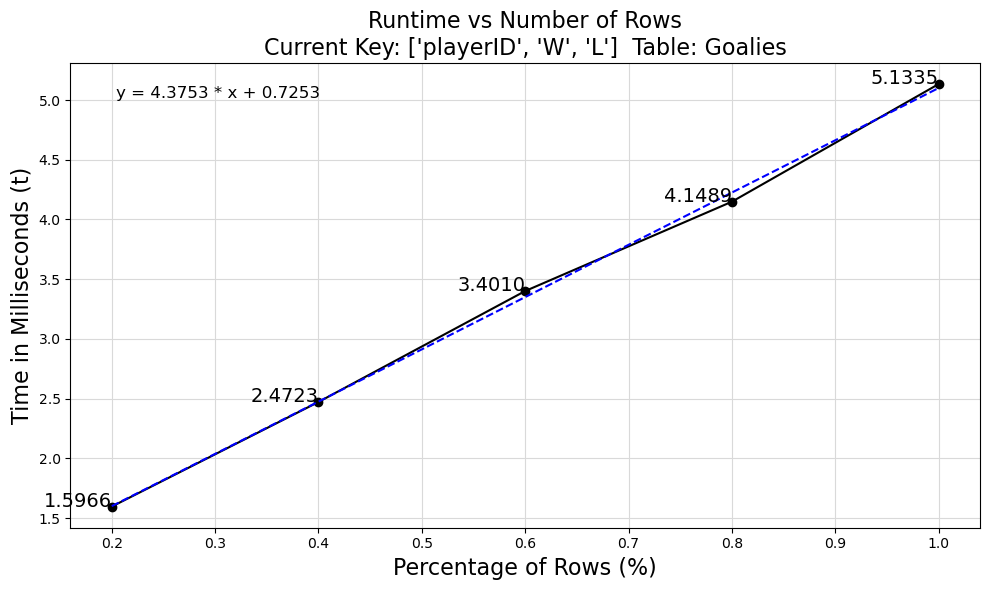

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/GoaliesRow.png
------------------------------------------------------------
[TABLE] Teams
Fitting Coefficients: y = 1.0105 * x + 0.7179
R^2: 0.9419


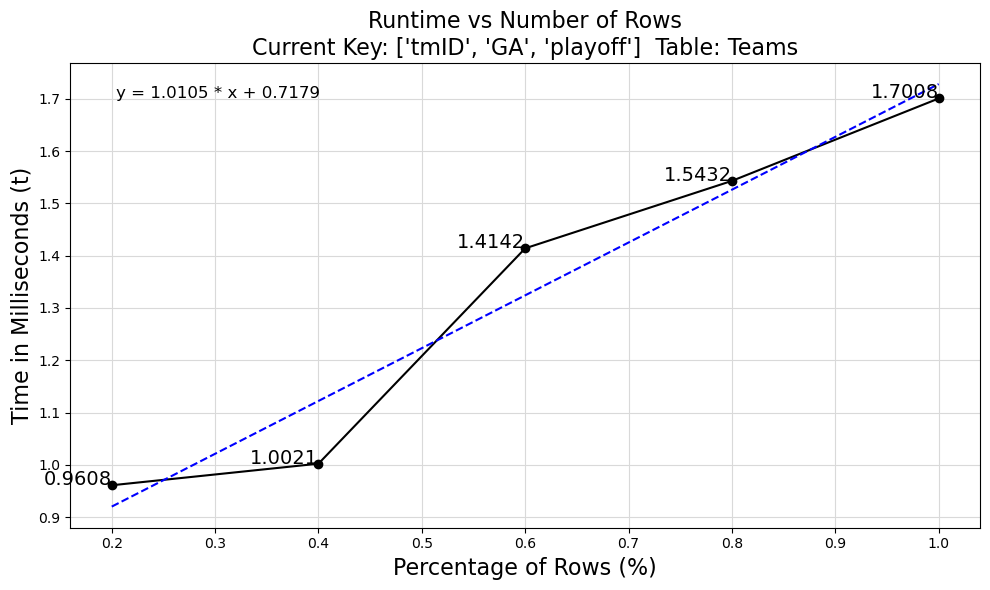

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/TeamsRow.png
------------------------------------------------------------
[TABLE] TeamVsTeam
Fitting Coefficients: y = 14.4472 * x + 1.4568
R^2: 0.9852


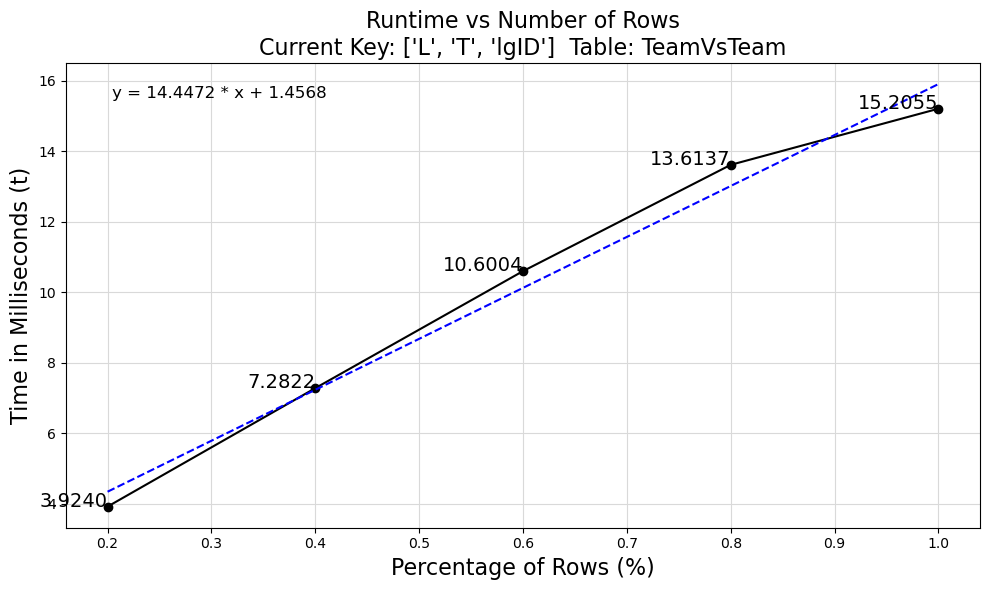

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/TeamVsTeamRow.png
------------------------------------------------------------
[TABLE] SeriesPost
Fitting Coefficients: y = 0.4819 * x + 0.5627
R^2: 0.8000


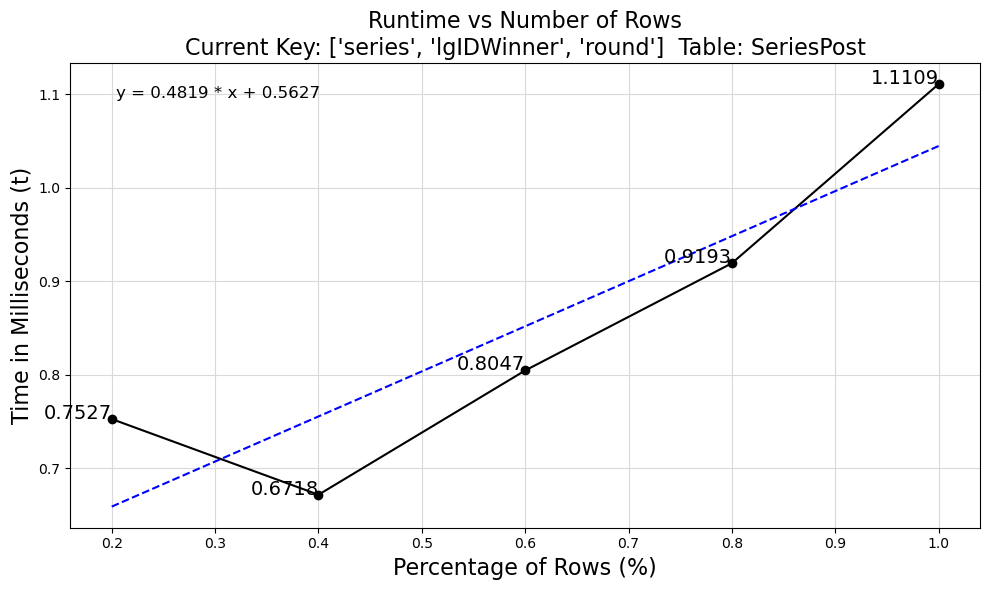

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/SeriesPostRow.png
------------------------------------------------------------
[TABLE] TeamsPost
Fitting Coefficients: y = 0.7950 * x + 0.5542
R^2: 0.8942


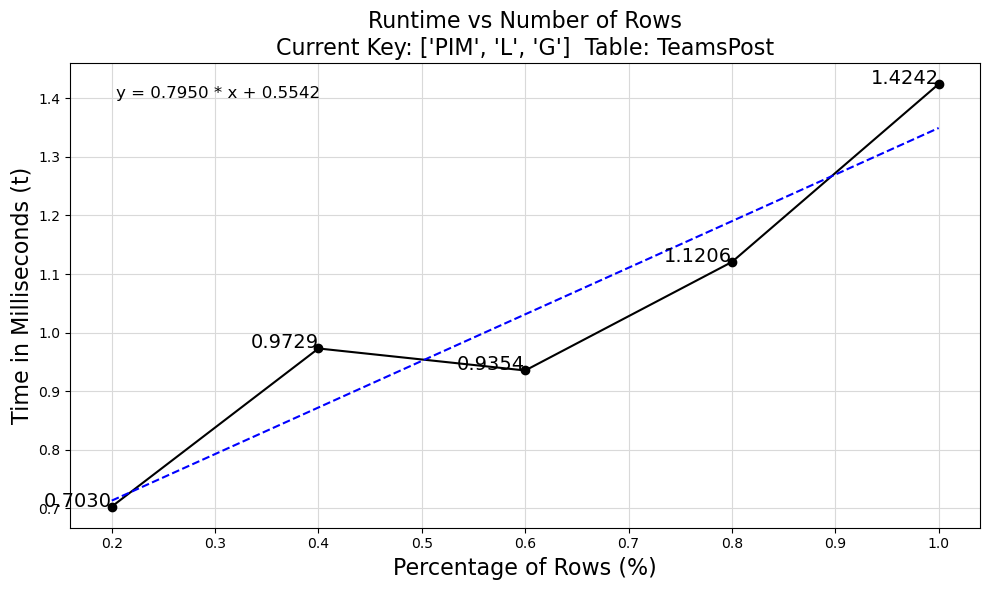

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/TeamsPostRow.png
------------------------------------------------------------
[TABLE] Coaches
Fitting Coefficients: y = 1.0815 * x + 0.6628
R^2: 0.9528


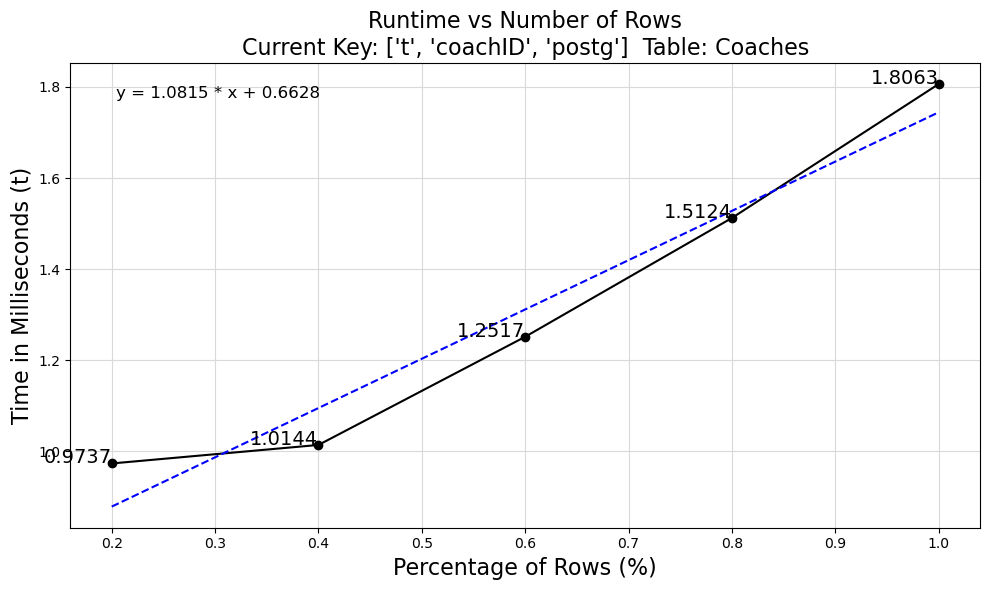

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/CoachesRow.png
------------------------------------------------------------
[TABLE] Scoring
Fitting Coefficients: y = 38.0356 * x + 0.4725
R^2: 0.9982


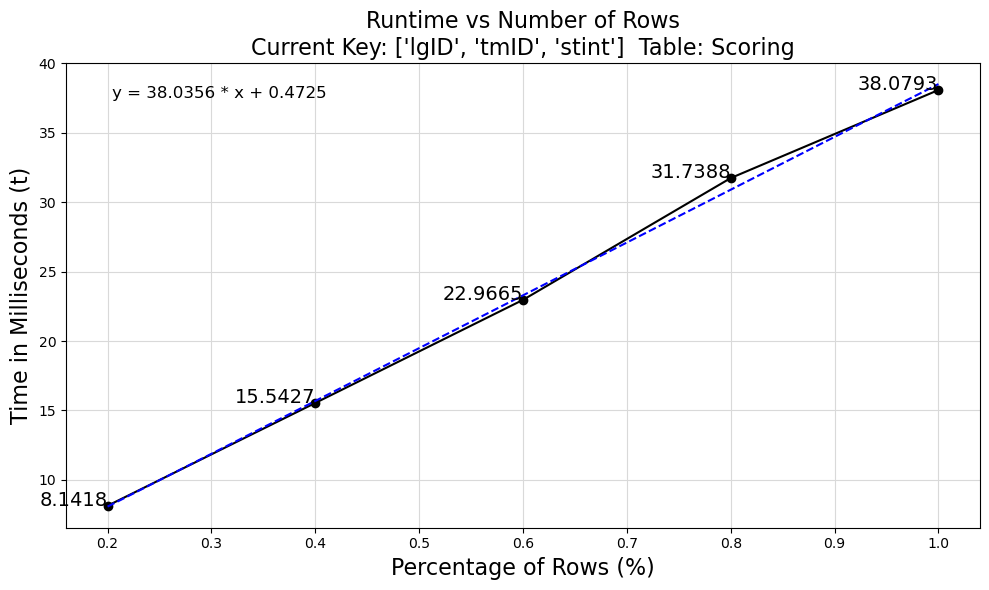

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/ScoringRow.png
------------------------------------------------------------
[TABLE] TeamSplits
Fitting Coefficients: y = 0.7015 * x + 0.7584
R^2: 0.8936


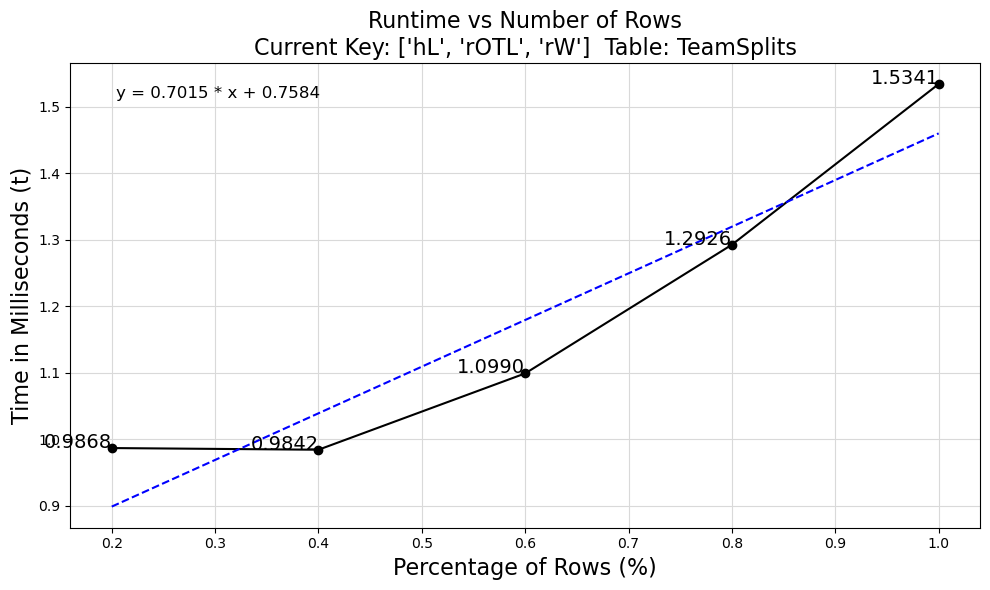

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/TeamSplitsRow.png
------------------------------------------------------------
[TABLE] AwardsPlayers
Fitting Coefficients: y = 1.0049 * x + 0.7512
R^2: 0.9519


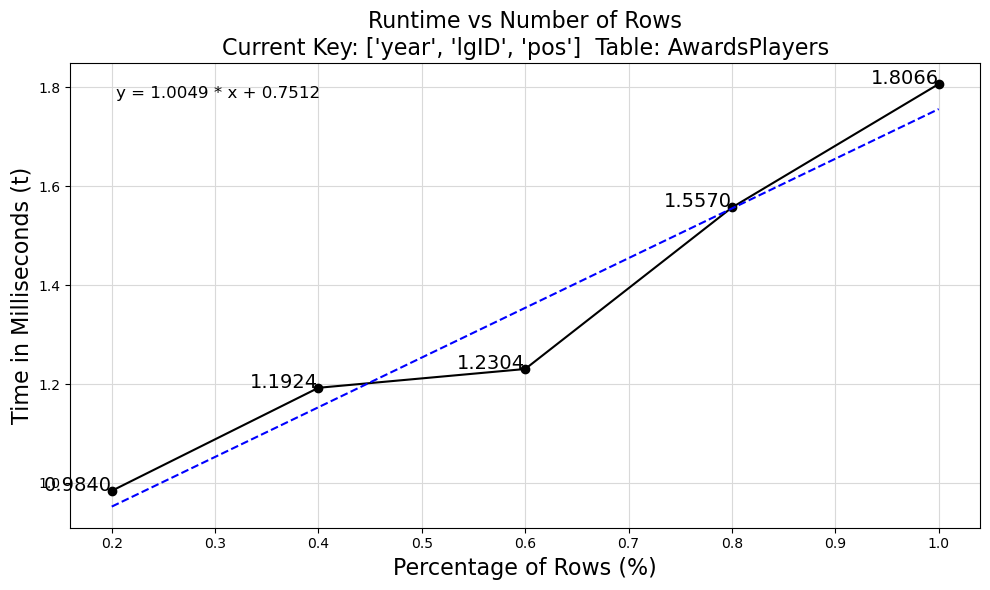

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/AwardsPlayersRow.png
------------------------------------------------------------
[TABLE] Master
Fitting Coefficients: y = 9.2370 * x + 0.4956
R^2: 0.9998


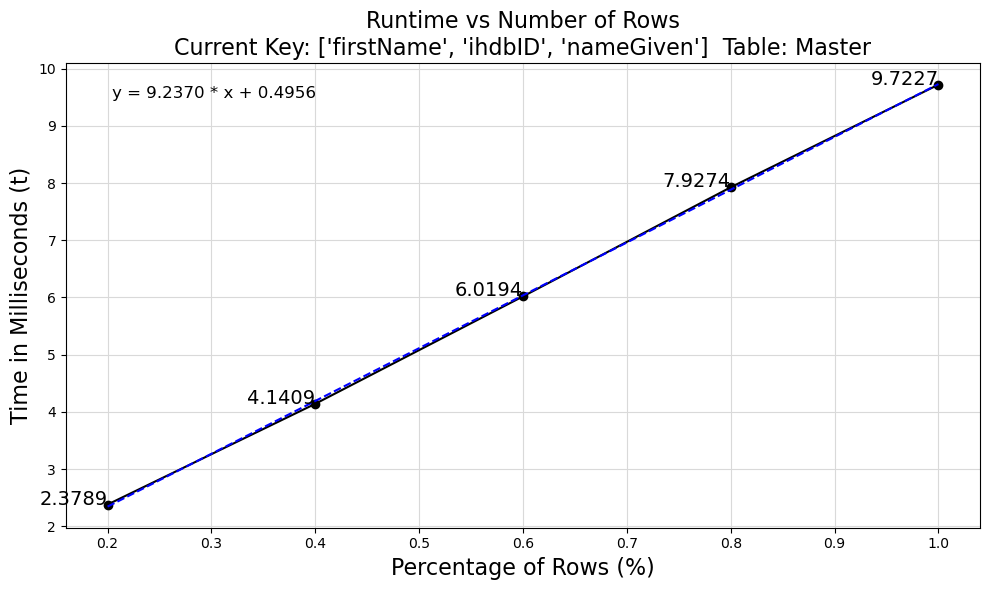

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/MasterRow.png
------------------------------------------------------------
[TABLE] HOF
Fitting Coefficients: y = 0.1650 * x + 0.7118
R^2: 0.4975


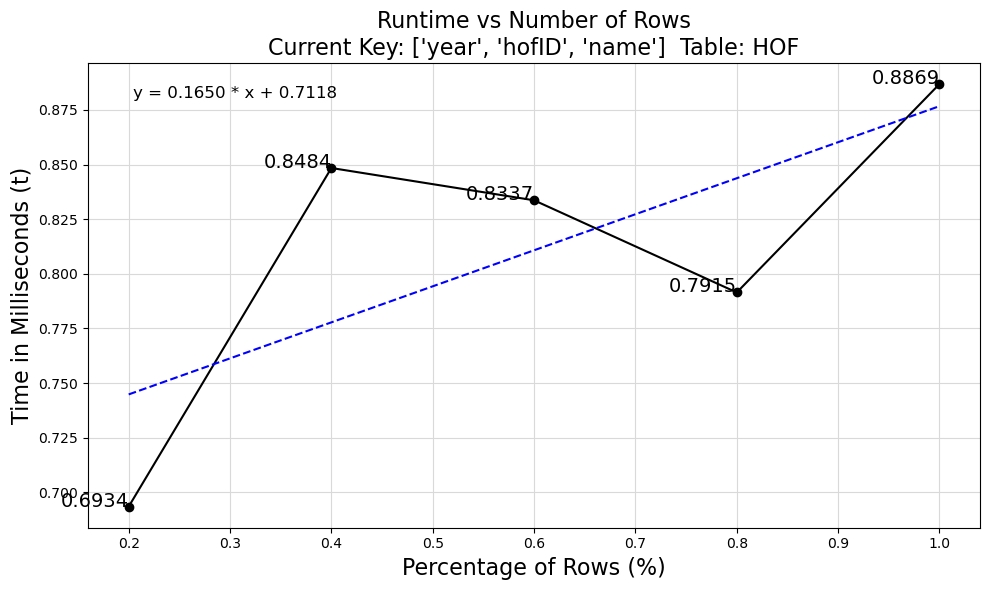

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/HOFRow.png
------------------------------------------------------------
[TABLE] AwardsMisc
Fitting Coefficients: y = -0.0819 * x + 0.5265
R^2: 0.4994


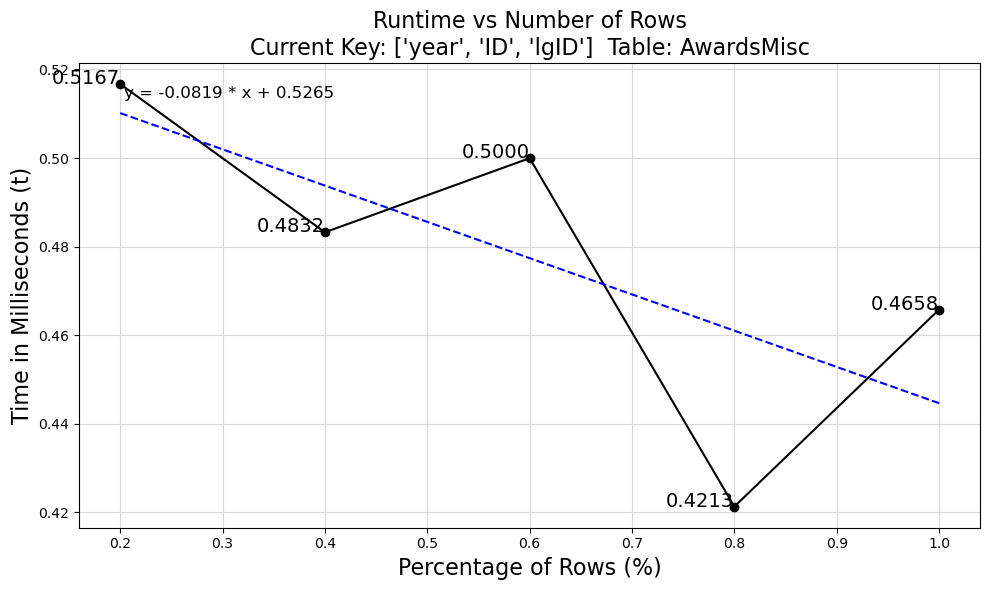

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/AwardsMiscRow.png
------------------------------------------------------------
[TABLE] Abbrev
Fitting Coefficients: y = -0.2262 * x + 0.6077
R^2: 0.7715


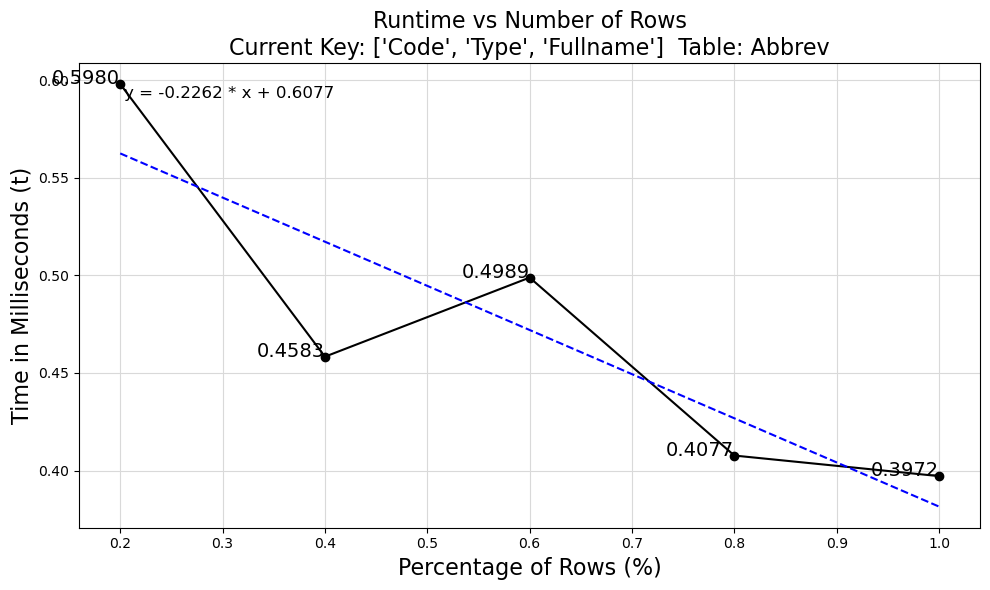

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/AbbrevRow.png
------------------------------------------------------------
[TABLE] TeamsHalf
Fitting Coefficients: y = -0.1489 * x + 0.5770
R^2: 0.5230


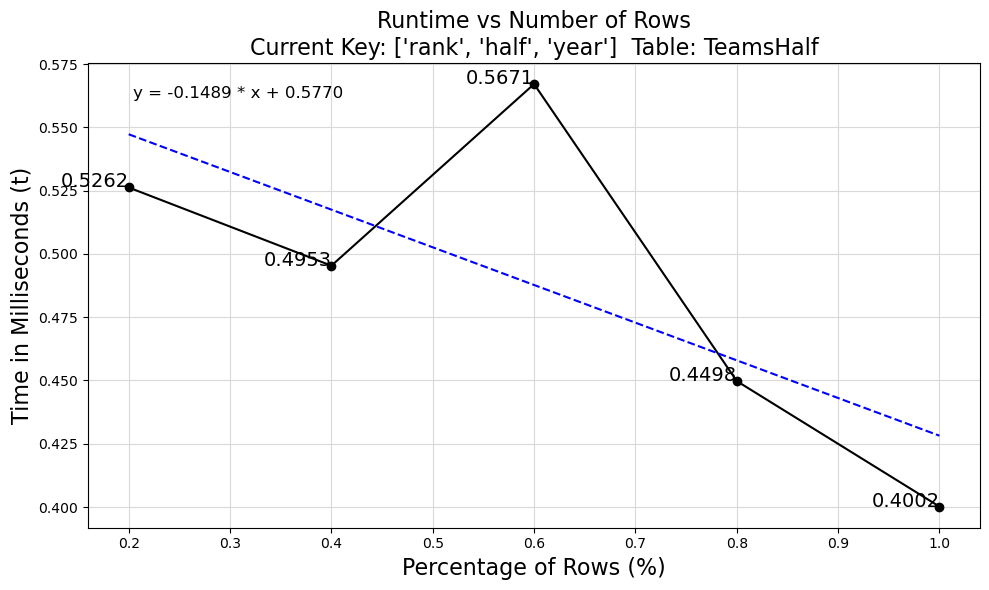

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/TeamsHalfRow.png
------------------------------------------------------------
[TABLE] GoaliesShootout
Fitting Coefficients: y = 0.2337 * x + 0.6520
R^2: 0.6038


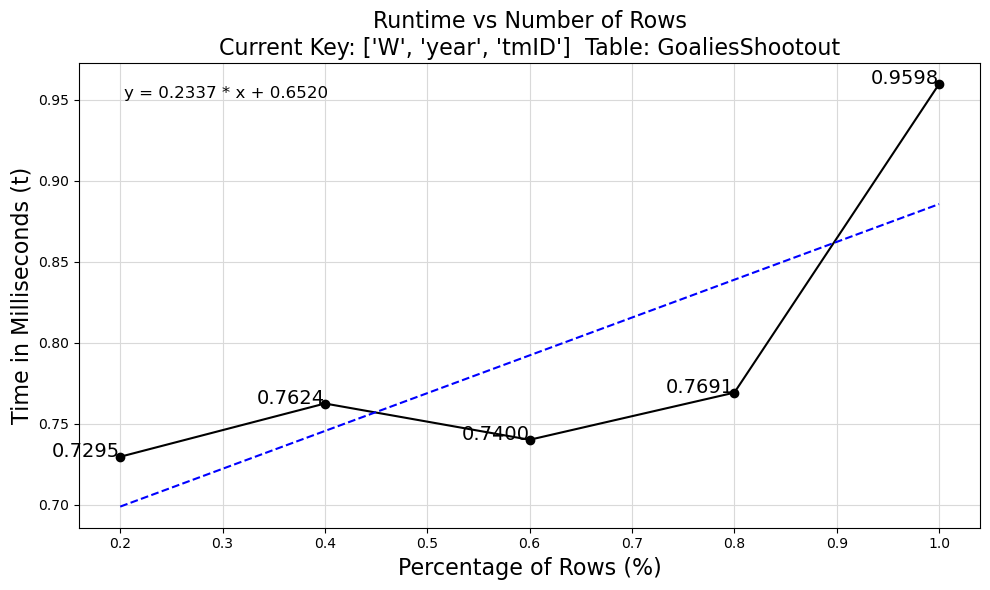

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/GoaliesShootoutRow.png
------------------------------------------------------------
[TABLE] ScoringSup
Fitting Coefficients: y = -0.1029 * x + 0.5059
R^2: 0.7996


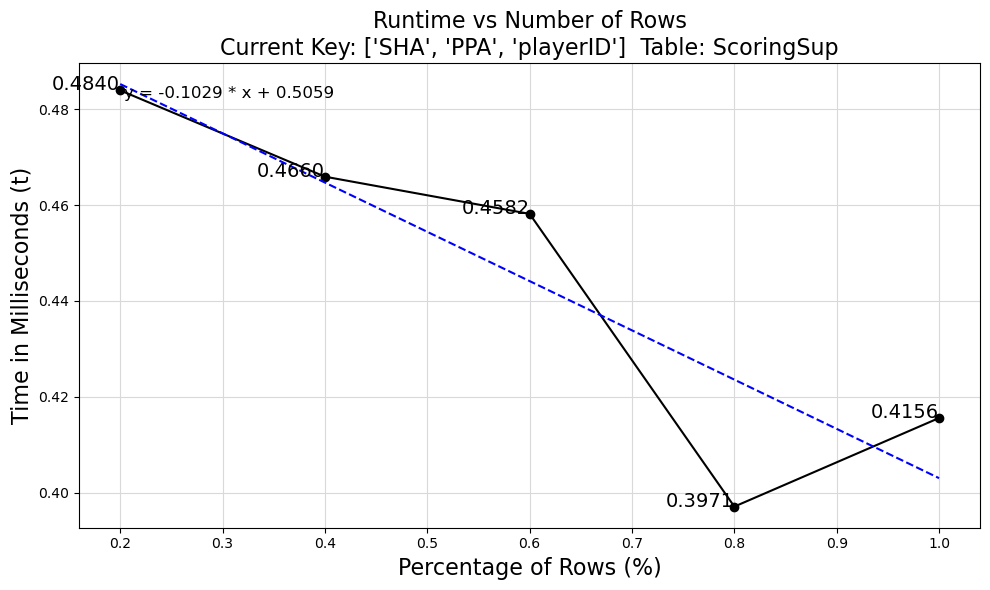

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/ScoringSupRow.png
------------------------------------------------------------
[TABLE] CombinedShutouts
Fitting Coefficients: y = -0.1487 * x + 0.5207
R^2: 0.8765


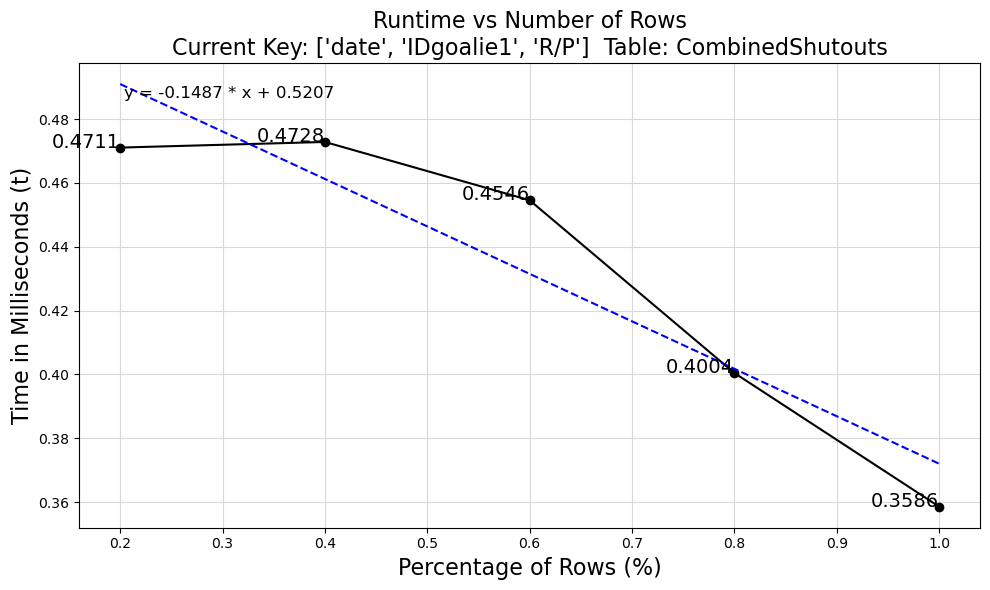

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/CombinedShutoutsRow.png
------------------------------------------------------------
[TABLE] ScoringSC
Fitting Coefficients: y = -0.0050 * x + 0.5867
R^2: 0.0017


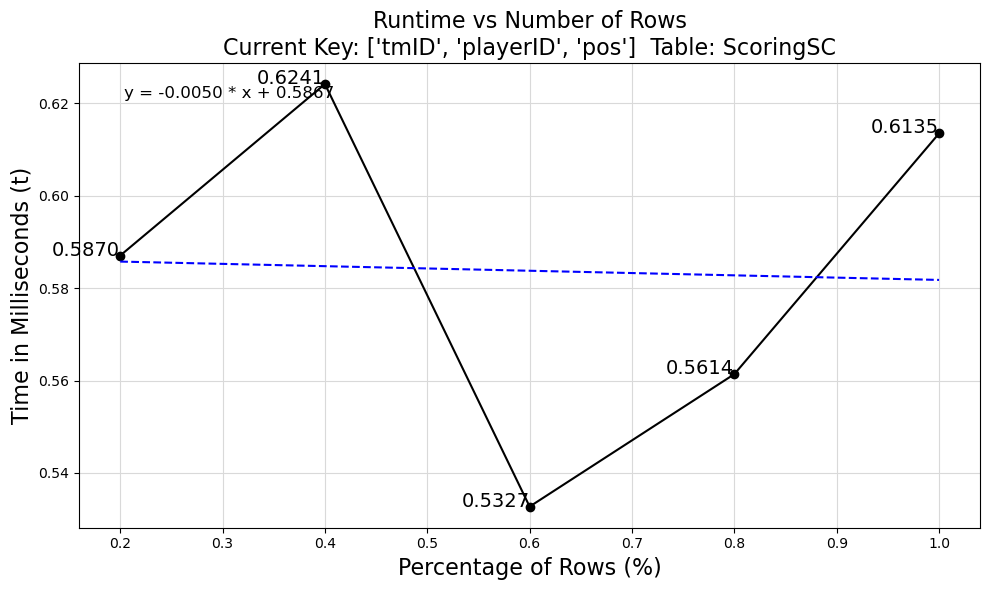

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/ScoringSCRow.png
------------------------------------------------------------
[TABLE] GoaliesSC
Fitting Coefficients: y = -0.1523 * x + 0.5380
R^2: 0.6989


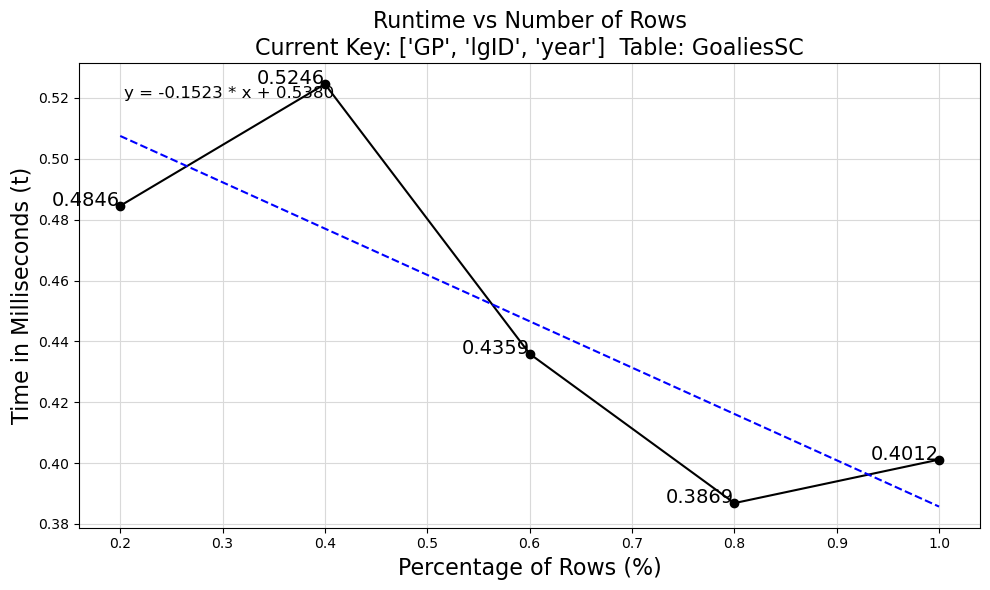

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/GoaliesSCRow.png
------------------------------------------------------------
[TABLE] ScoringShootout
Fitting Coefficients: y = 0.9995 * x + 0.6460
R^2: 0.9336


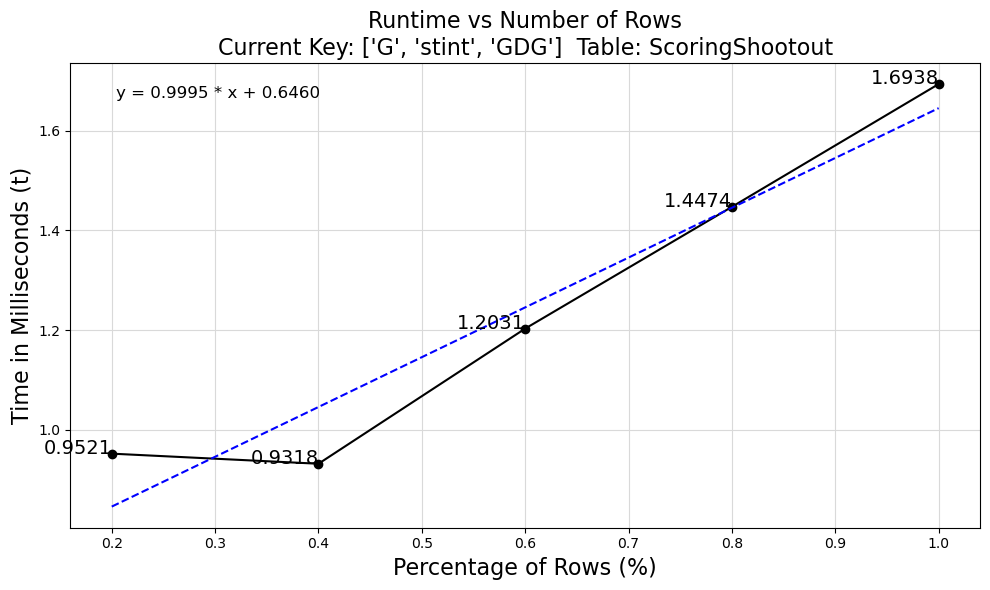

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/ScoringShootoutRow.png
------------------------------------------------------------
[TABLE] TeamsSC
Fitting Coefficients: y = -0.1935 * x + 0.5185
R^2: 0.8921


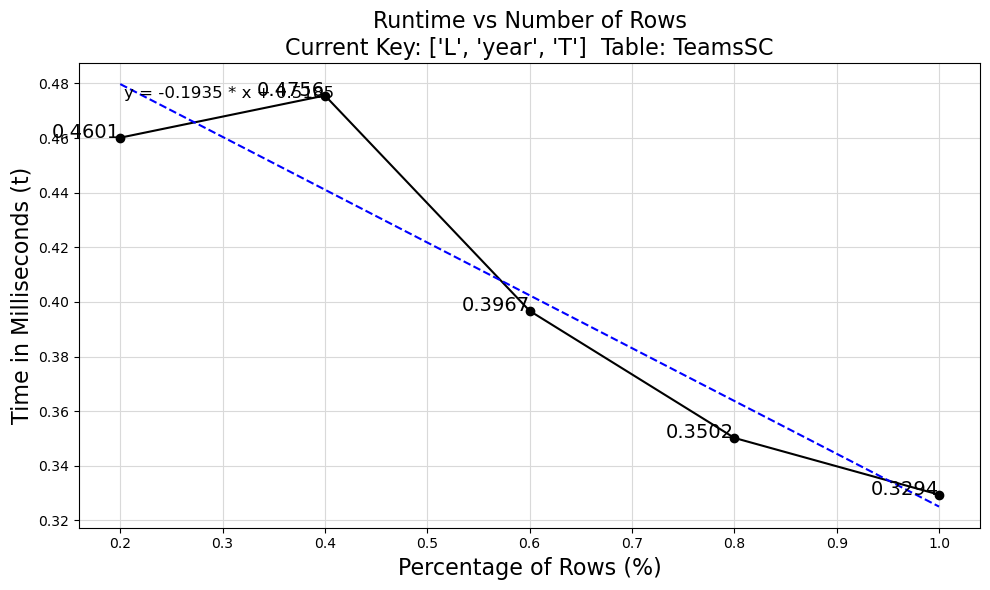

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/TeamsSCRow.png
total_avg_execution_times_precentage: [{0.2: 1.5965938568115234, 0.4: 2.472257614135742, 0.6: 3.4009933471679688, 0.8: 4.14891242980957, 1.0: 5.133533477783203}, {0.2: 0.9608268737792969, 0.4: 1.0021209716796875, 0.6: 1.4141559600830078, 0.8: 1.5431880950927734, 1.0: 1.7008304595947266}, {0.2: 3.9240360260009766, 0.4: 7.282161712646484, 0.6: 10.60037612915039, 0.8: 13.613653182983398, 1.0: 15.205526351928711}, {0.2: 0.7527351379394531, 0.4: 0.6718158721923828, 0.6: 0.8046627044677734, 0.8: 0.919342041015625, 1.0: 1.1108875274658203}, {0.2: 0.7030487060546875, 0.4: 0.9729385375976562, 0.6: 0.93536376953125, 0.8: 1.1205673217773438, 1.0: 1.4242172241210938}, {0.2: 0.9737491607666016, 0.4: 1.0143756866455078, 0.6: 1.2517452239990234, 0.8: 1.5124320983886719, 1.0: 1.8062591552734375}, {0.2: 8.141756057739258, 0.4: 15.54269790649414, 0.6: 22.966527938842773, 0.8: 31.738758087158203, 1.0: 38.0

In [4]:
total_avg_execution_times_precentage = []
total_avg_execution_times = []

connection = None
cursor = None

try:
    connection = mysql.connector.connect(**DB_CONFIG)
    cursor = connection.cursor()

    for table_name, cols in random_l1.items():
        print("------------------------------------------------------------")
        print(f"[TABLE] {table_name}")

        avg_execution_times_precentage = main_sql_row_precentage(
            cursor,
            table_name,
            cols,
            num=5,
            row_percentages=[0.2, 0.4, 0.6, 0.8, 1.0],
        )
        total_avg_execution_times_precentage.append(avg_execution_times_precentage)

        # avg_execution_times = main_sql_row(
        #     cursor,
        #     table_name,
        #     cols,
        #     num=5,
        #     row_nums=[1000, 2000, 3000, 4000, 5000, 6000, 7000],
        # )
        # total_avg_execution_times.append(avg_execution_times)

finally:
    if cursor is not None:
        cursor.close()
    if connection is not None and connection.is_connected():
        connection.close()

print(f"total_avg_execution_times_precentage: {total_avg_execution_times_precentage}")
# print(f"total_avg_execution_times: {total_avg_execution_times}")


# Average Running Time

Polynomial Fit (degree=1): y = 3.4052 * x^1 + 0.6452 * x^0
R^2 (degree=1): 0.9993
Polynomial Fit (degree=2): y = -0.1327 * x^2 + 3.5644 * x^1 + 0.6080 * x^0
R^2 (degree=2): 0.9994
Polynomial Fit (degree=3): y = -1.6545 * x^3 + 2.8454 * x^2 + 2.0026 * x^1 + 0.8304 * x^0
R^2 (degree=3): 0.9999
Exponential Fit: y = 1.2069 * e^(1.2385 * x)
R^2 (exponential): 0.9749


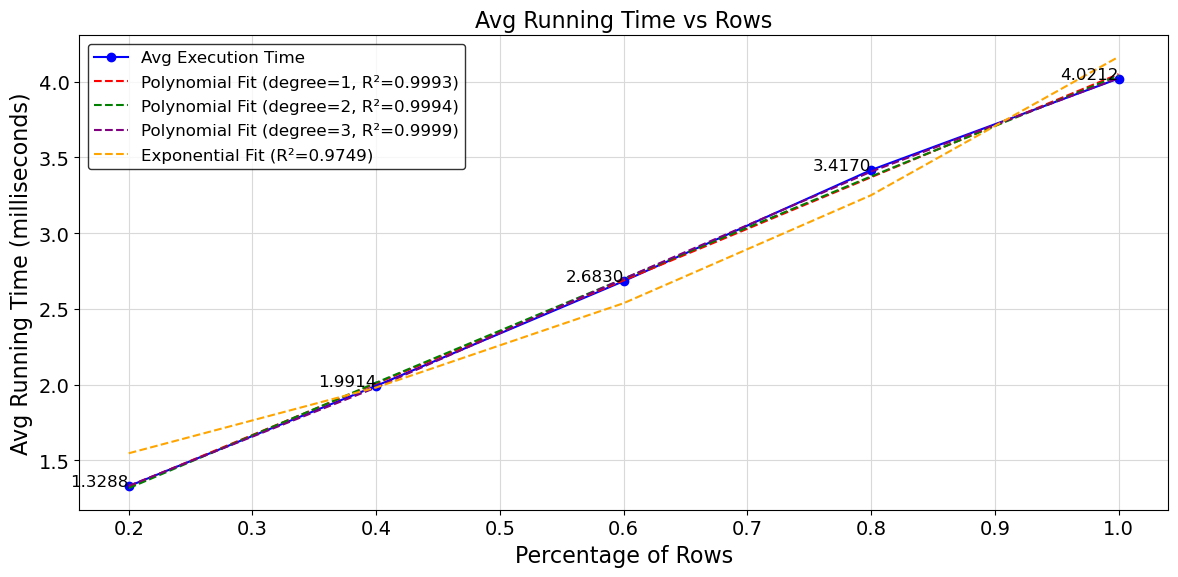

✅ Saved to: /Users/zihuiyang/PycharmProjects/Identify_key/evaluation/rowRunTime/change_row_fitting.png


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

def fit_curve2(lengths, times, degree=1):
    """Fit a polynomial curve of given degree to the lengths and times."""
    coefficients = np.polyfit(lengths, times, degree)
    polynomial = np.poly1d(coefficients)
    fitted_values = polynomial(lengths)
    SS_res = np.sum((times - fitted_values) ** 2)
    SS_tot = np.sum((times - np.mean(times)) ** 2)
    r_squared = 1 - (SS_res / SS_tot)
    return polynomial, coefficients, r_squared


def exponential_func(x, a, b):
    """Exponential function for curve fitting."""
    return a * np.exp(b * x)


# ---------------- 数据处理 ----------------
average_times_precentage = {}
for key in total_avg_execution_times_precentage[0].keys():
    average_times_precentage[key] = sum(d[key] for d in total_avg_execution_times_precentage) / len(total_avg_execution_times_precentage)

keys = np.array(list(average_times_precentage.keys()))
runtime = np.array(list(average_times_precentage.values()))

# ---------------- 多项式拟合 ----------------
fit_results = {}
for degree in [1, 2, 3]:
    polynomial, coefficients, r_squared = fit_curve2(keys, runtime, degree=degree)
    fit_results[degree] = {
        'polynomial': polynomial,
        'coefficients': coefficients,
        'r_squared': r_squared
    }

# ---------------- 指数拟合 ----------------
popt, pcov = curve_fit(exponential_func, keys, runtime, p0=(1, 0.1))
a, b = popt
fitted_exponential = exponential_func(keys, a, b)
residuals_exp = runtime - fitted_exponential
SS_res_exp = np.sum(residuals_exp ** 2)
SS_tot_exp = np.sum((runtime - np.mean(runtime)) ** 2)
r_squared_exp = 1 - (SS_res_exp / SS_tot_exp)

# ---------------- 输出拟合结果 ----------------
for degree in [1, 2, 3]:
    coefficients = fit_results[degree]['coefficients']
    r_squared = fit_results[degree]['r_squared']
    formula = " + ".join([f"{coefficients[i]:.4f} * x^{len(coefficients) - i - 1}" for i in range(len(coefficients))])
    print(f"Polynomial Fit (degree={degree}): y = {formula}")
    print(f"R^2 (degree={degree}): {r_squared:.4f}")

print(f"Exponential Fit: y = {a:.4f} * e^({b:.4f} * x)")
print(f"R^2 (exponential): {r_squared_exp:.4f}")

# ---------------- 绘图（强制白底黑字） ----------------
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
})

fig, ax = plt.subplots(figsize=(12, 6))

# ✅ 强制白底
fig.set_facecolor("white")
ax.set_facecolor("white")

# ✅ 强制坐标轴 / 刻度 / 标题文字全黑
ax.tick_params(axis="both", colors="black")
ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")
ax.title.set_color("black")

# ✅ 坐标轴边框黑色
for spine in ax.spines.values():
    spine.set_color("black")

# ---------------- 数据曲线 ----------------
ax.plot(keys, runtime, marker="o", linestyle="-", color="blue", label="Avg Execution Time")

colors = ["red", "green", "purple"]
for i, degree in enumerate([1, 2, 3]):
    polynomial = fit_results[degree]["polynomial"]
    r_squared = fit_results[degree]["r_squared"]
    ax.plot(
        keys,
        polynomial(keys),
        linestyle="--",
        color=colors[i],
        label=f"Polynomial Fit (degree={degree}, R²={r_squared:.4f})"
    )

ax.plot(
    keys,
    fitted_exponential,
    linestyle="--",
    color="orange",
    label=f"Exponential Fit (R²={r_squared_exp:.4f})"
)

# ---------------- 数值标注（强制黑色） ----------------
for i, key in enumerate(keys):
    ax.text(key, runtime[i], f"{runtime[i]:.4f}", fontsize=12, color="black", ha="right")

# ---------------- 轴标签/标题 ----------------
ax.set_xlabel("Percentage of Rows")
ax.set_ylabel("Avg Running Time (milliseconds)")
ax.set_title("Avg Running Time vs Rows")

# ✅ 网格线浅灰（更清晰）
ax.grid(True, color="0.85")

# ---------------- legend（强制白底黑字） ----------------
leg = ax.legend(frameon=True)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("black")
for t in leg.get_texts():
    t.set_color("black")

fig.tight_layout()


# ---------------- 保存路径：当前文件所在目录 / 当前工作目录 ----------------
save_dir = Path.cwd() / "rowRunTime"
save_dir.mkdir(parents=True, exist_ok=True)

file_name = "change_row_fitting.png"
file_path = save_dir / file_name

plt.savefig(str(file_path), dpi=300, facecolor="white")
plt.show()

print(f"✅ Saved to: {file_path.resolve()}")